In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import h5py as h5
from scipy.optimize import curve_fit
import scienceplots

plt.style.use('science')

In [2]:
def fit_func(x, a, b):
    return a*x**b

In [3]:
src_dir = Path("/data/lmp/aarnhold/dynamical_scaling/")
sim_names = ["L250", "L500", "L750", "L1000", "L2000"]
sims = [(src_dir/sim_name).with_suffix(".h5") for sim_name in sim_names]

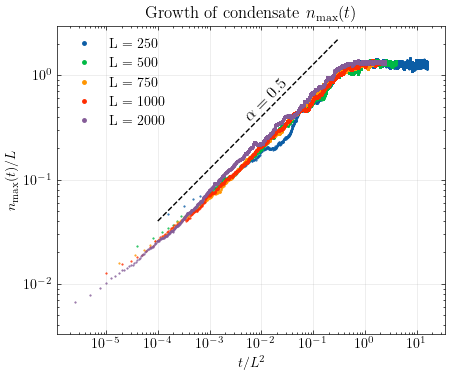

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

for sim in sims:
    with h5.File(sim, "r") as fid:
        dset = fid["avg_maxs"]
        L = fid.attrs["L"]
        time = fid.attrs["t"]

        t_skip = 10
        n_max = dset[0, ::t_skip]
        t = np.arange(len(n_max))

        ax.grid(alpha=0.3)
        ax.plot(t/(L**2)*t_skip, n_max/L, label=fr"L = {L}", 
                  lw=0, marker="o", markersize=.5, alpha=1)
        ax.set_xlabel(r"$t / L^2$")
        ax.set_ylabel(r"$n_{\text{max}}(t) / L$")
        ax.set_title(r"Growth of condensate $n_{\text{max}}(t)$")
        ax.legend(markerscale=5., loc="upper left")
        
        
t_theo = np.linspace(1e-4, 3e-1, 1000)
offset = 4
n_max_theo = offset*np.sqrt(t_theo)
ax.loglog(t_theo, n_max_theo, ls="--", c="black")

text_loc=20
extra_offset = 1.15
dy = (n_max_theo[text_loc+1] - n_max_theo[text_loc-1])/2
dx = (t_theo[text_loc+1] - t_theo[text_loc-1])/2
angle = np.rad2deg(np.arctan2(extra_offset*dy, dx))
ax.text(t_theo[text_loc], extra_offset*n_max_theo[text_loc], r"$\alpha = 0.5$",
        fontsize=12, rotation_mode='anchor', rotation=angle, 
        transform_rotates_text=True)
fig.savefig("../data/growth_of_condensate_exponent.png", format="png")

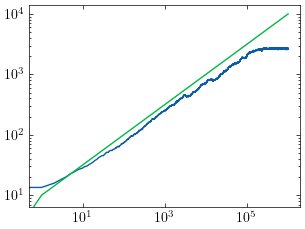

In [32]:
fig, ax = plt.subplots(1, 1)
ax.loglog(t, n_max)
ax.loglog(t, 10*t**(1/2))

a = 10.242, dk = 0.02223989093016161
k = 0.459, dk = 0.00019733324853888883


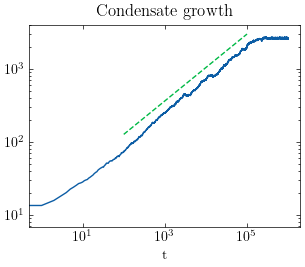

In [49]:
t0, t1 = int(1e2), int(1e5)
popt, pcov = curve_fit(fit_func, t[t0:t1], n_max[t0:t1])

fig, ax = plt.subplots(1, 1)
ax.set_title("Condensate growth")
ax.loglog(t, n_max, label="data")
ax.loglog(t[t0:t1], fit_func(t[t0:t1], *popt)*1.5, ls="--")
ax.set_xlabel(r"t")
ax.hlines(.2, xmin=1e-6, xmax=1)

print(f"a = {popt[0]:.3f}, dk = {np.sqrt(pcov[0, 0])}")
print(f"k = {popt[1]:.3f}, dk = {np.sqrt(pcov[1, 1])}")